This notebook implements, from scratch with **NumPy**, the derivation worked out in [Two-Class, Two-Feature Linear Classifier](two-class-linear.qmd). We build up the pieces one step at a time — data, feature matrix, prediction, loss, gradient, and the gradient-descent loop — and each function states the math in vector/matrix form in its docstring/comments.

**Notation.** For sample $i$, $\mathbf{x}^{(i)} = [\,1,\ x_1^{(i)},\ x_2^{(i)}\,]$, weights $\mathbf{w} = [\,w_0, w_1, w_2\,]^\top$, sigmoid $g(z) = \tfrac{1}{1+e^{-z}}$, and prediction $\hat{y} = g(X\mathbf{w})$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible randomness for the simulated dataset.
rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

## Step 1 — Generate the training dataset (simulation)

We simulate two classes as two Gaussian blobs in the raw feature space $(x_1, x_2)$: class **a** (label $0$) and class **b** (label $1$).

In [2]:
def generate_data(n_per_class=100):
    """Simulate a (mostly) linearly-separable, two-class dataset in 2D.

    Returns
    -------
    X_raw : (n, 2) array   raw features [x1, x2]
    y     : (n,)  array    labels in {0, 1}  (0 = class a, 1 = class b)
    """
    # Two Gaussian clusters with well-separated means.
    mean_a, mean_b = np.array([2.0, 6.0]), np.array([6.0, 2.0])
    cov = np.array([[1.3, 0.0],
                    [0.0, 1.3]])
    Xa = rng.multivariate_normal(mean_a, cov, size=n_per_class)  # class a
    Xb = rng.multivariate_normal(mean_b, cov, size=n_per_class)  # class b

    X_raw = np.vstack([Xa, Xb])
    y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

    # Shuffle so the two classes are interleaved.
    perm = rng.permutation(len(y))
    return X_raw[perm], y[perm]


X_raw, y = generate_data(n_per_class=100)
print("X_raw:", X_raw.shape, " y:", y.shape)
print("class counts -> a(0):", int((y == 0).sum()), " b(1):", int((y == 1).sum()))

X_raw: (200, 2)  y: (200,)
class counts -> a(0): 100  b(1): 100


## Step 2 — Visualize the sample data

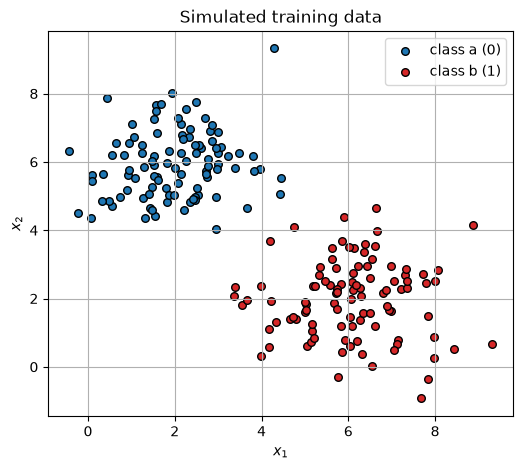

In [3]:
def plot_points(ax, X_raw, y):
    """Scatter the raw samples, coloured by class."""
    ax.scatter(X_raw[y == 0, 0], X_raw[y == 0, 1], c="#1f77b4",
               label="class a (0)", edgecolor="k", s=30)
    ax.scatter(X_raw[y == 1, 0], X_raw[y == 1, 1], c="#d62728",
               label="class b (1)", edgecolor="k", s=30)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.legend(loc="best")


fig, ax = plt.subplots()
plot_points(ax, X_raw, y)
ax.set_title("Simulated training data")
plt.show()

## Step 3 — Construct the feature matrix

In [4]:
def build_feature_matrix(X_raw):
    """Prepend a bias column of ones to the raw features.

    Math:  each row becomes  x^(i) = [1, x1^(i), x2^(i)]
           so the design matrix is

               X = [[1, x1^(1), x2^(1)],
                    [1, x1^(2), x2^(2)],
                    ...,
                    [1, x1^(n), x2^(n)]]    with shape (n, 3)

    The leading 1 lets w0 act as the bias/intercept in  h = X w.
    """
    n = X_raw.shape[0]
    ones = np.ones((n, 1))
    return np.hstack([ones, X_raw])   # (n, 3)


X = build_feature_matrix(X_raw)
print("X:", X.shape)
print("first row [1, x1, x2]:", np.round(X[0], 3))

X: (200, 3)
first row [1, x1, x2]: [1.    1.563 7.666]


## Step 4 — Transform (prediction) function

The model's forward pass, analogous to scikit-learn's `model.predict_proba` / `model.predict`.

In [5]:
def sigmoid(z):
    """Numerically-stable logistic sigmoid  g(z) = 1 / (1 + e^{-z})."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos, neg = z >= 0, z < 0
    # For z >= 0 use 1/(1+e^-z); for z < 0 use e^z/(1+e^z). Both avoid overflow.
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out


def predict_proba(X, w):
    """P(y = 1 | x, w) for each row:  yhat = g(X w).

    X : (n, 3),  w : (3,)  ->  h = X w : (n,)  ->  g(h) : (n,)
    """
    return sigmoid(X @ w)


def predict(X, w, threshold=0.5):
    """Hard class labels: 1 if g(X w) >= threshold else 0."""
    return (predict_proba(X, w) >= threshold).astype(int)

## Step 5 — Objective (loss) function

In [6]:
def loss(X, y, w, eps=1e-12):
    """Negative log-likelihood, summed over samples -- exactly as in the notes.

    Math (with p = g(X w)):

        L = -ln(P) = -sum_i [ y^(i) ln p^(i) + (1 - y^(i)) ln(1 - p^(i)) ]

    We sum (not average) so this matches the by-hand derivation literally.
    """
    p = predict_proba(X, w)
    p = np.clip(p, eps, 1.0 - eps)              # keep the logs finite
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

## Step 6 — Gradient of the loss

In [7]:
def gradient(X, y, w):
    """Gradient of the (summed) negative log-likelihood w.r.t. w.

    Math (the key result derived by hand in the notes):

        dL/dw = X^T ( g(X w) - y )

    Shapes:  X^T : (3, n),  (g(Xw) - y) : (n,)  ->  grad : (3,)

    Component-wise:  dL/dw_j = sum_i ( g(x^(i).w) - y^(i) ) x_j^(i),
    i.e. the prediction error weighted by each feature (x_0 = 1 for the bias).
    """
    error = predict_proba(X, w) - y             # (n,)
    return X.T @ error                           # (3,)

## Step 7 — Gradient descent algorithm

In [8]:
def gradient_descent(X, y, lr=5e-4, n_iters=5000, w0=None):
    """Batch gradient descent on the summed negative log-likelihood.

    Update rule (from the notes):

        w <- w - eta * dL/dw = w - eta * X^T ( g(X w) - y )

    Because the loss/gradient are summed (not averaged), the learning rate eta
    is smaller than it would be for the mean form (roughly by a factor of n).

    Parameters
    ----------
    lr : learning rate eta
    n_iters : number of full-batch iterations

    Returns the fitted weights and the loss history (for the learning curve).
    """
    w = np.zeros(X.shape[1]) if w0 is None else np.array(w0, dtype=float)
    history = np.empty(n_iters)
    for t in range(n_iters):
        w = w - lr * gradient(X, y, w)          # descent step
        history[t] = loss(X, y, w)
    return w, history

## Step 8 — Train the classifier

learned weights  w = [w0, w1, w2] = [ 0.1907  2.9799 -2.9906]
final loss: 0.707941


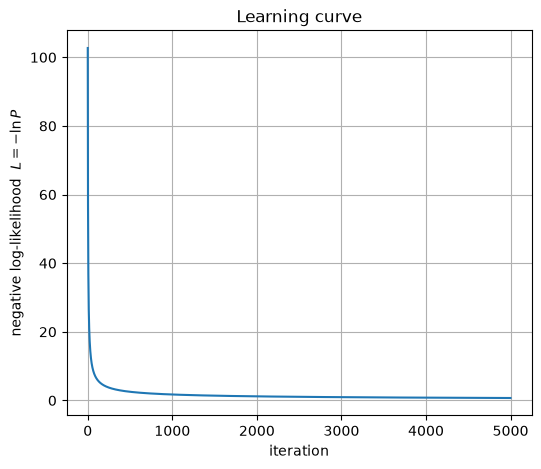

In [9]:
w, history = gradient_descent(X, y, lr=5e-4, n_iters=5000)
print("learned weights  w = [w0, w1, w2] =", np.round(w, 4))
print("final loss:", round(float(history[-1]), 6))

fig, ax = plt.subplots()
ax.plot(history)
ax.set_xlabel("iteration"); ax.set_ylabel("negative log-likelihood  $L = -\\ln P$")
ax.set_title("Learning curve")
plt.show()

## Step 9 — Evaluate: accuracy & confusion matrix

In [10]:
def accuracy(y_true, y_pred):
    """Fraction of correct predictions."""
    return float(np.mean(y_true == y_pred))


def confusion_matrix(y_true, y_pred):
    """Return [[TN, FP], [FN, TP]] for labels in {0, 1}."""
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return np.array([[tn, fp], [fn, tp]])


y_hat = predict(X, w)
cm = confusion_matrix(y, y_hat)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall    = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

print(f"accuracy : {accuracy(y, y_hat):.3f}")
print(f"precision: {precision:.3f}   recall: {recall:.3f}   f1: {f1:.3f}")
print("confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

accuracy : 1.000
precision: 1.000   recall: 1.000   f1: 1.000
confusion matrix [[TN, FP], [FN, TP]]:
[[100   0]
 [  0 100]]


## Step 10 — Visualize the decision boundary

The boundary is where $P(y{=}1)=0.5$, i.e. $w_0 + w_1 x_1 + w_2 x_2 = 0$, which gives the line $x_2 = -(w_0 + w_1 x_1)/w_2$.

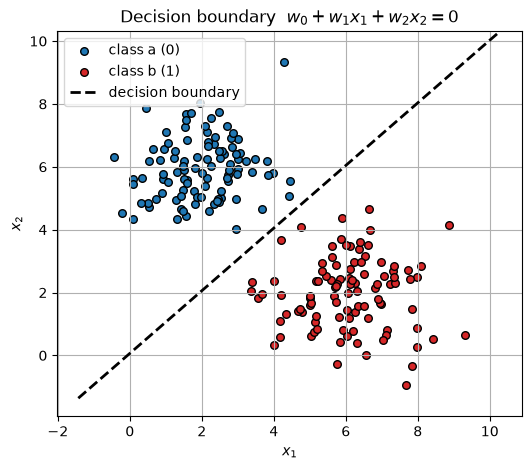

In [11]:
fig, ax = plt.subplots()
plot_points(ax, X_raw, y)

# Solve w0 + w1*x1 + w2*x2 = 0  for x2 across the observed x1 range.
x1_line = np.linspace(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1, 200)
x2_line = -(w[0] + w[1] * x1_line) / w[2]
ax.plot(x1_line, x2_line, "k--", lw=2, label="decision boundary")

ax.set_title("Decision boundary  $w_0 + w_1 x_1 + w_2 x_2 = 0$")
ax.legend(loc="best")
ax.set_ylim(X_raw[:, 1].min() - 1, X_raw[:, 1].max() + 1)
plt.show()

## Step 11 — Full-field classification over a $(x_1, x_2)$ meshgrid

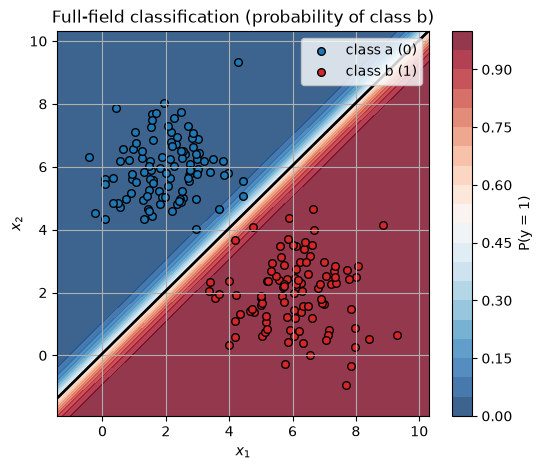

In [12]:
# Build a dense grid over the raw feature space.
pad = 1.0
x1_min, x1_max = X_raw[:, 0].min() - pad, X_raw[:, 0].max() + pad
x2_min, x2_max = X_raw[:, 1].min() - pad, X_raw[:, 1].max() + pad
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                       np.linspace(x2_min, x2_max, 300))

# Feature matrix for every grid point, then predicted probability P(y = 1).
grid_raw = np.column_stack([xx1.ravel(), xx2.ravel()])
grid_X = build_feature_matrix(grid_raw)
proba = predict_proba(grid_X, w).reshape(xx1.shape)

fig, ax = plt.subplots()
cf = ax.contourf(xx1, xx2, proba, levels=20, cmap="RdBu_r", alpha=0.8)
ax.contour(xx1, xx2, proba, levels=[0.5], colors="k", linewidths=2)  # boundary
plot_points(ax, X_raw, y)
fig.colorbar(cf, ax=ax, label="P(y = 1)")
ax.set_title("Full-field classification (probability of class b)")
plt.show()

## Recap

Following the [derivation](two-class-linear.qmd), we built a logistic-regression classifier end-to-end with only NumPy:

1. simulated two-class data,
2. added a bias column to form $X$,
3. defined the prediction $g(X\mathbf{w})$,
4. the negative log-likelihood loss $L=-\ln P$,
5. its gradient $X^\top(g(X\mathbf{w}) - \mathbf{y})$, and
6. the gradient-descent update $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla L$.

The learned linear boundary separates the two classes, and the meshgrid view shows the full probability field — exactly the picture the hand derivation was building toward.

← Back to the note: [Two-Class, Two-Feature Linear Classifier](two-class-linear.qmd).